In [ ]:
# Week 2 Coding Vignette


# We are going to go through a simplified version of the Chapter 2 notebook of Hands on Machine Learning


In [2]:
# Normal python style is to load all libraries at the top but we will tend to load them as we go

# This is the main machine learning library with most of the key functions
# We will import a variety of submodules from it a we go

import sklearn

# Pandas and numpy
import pandas as pd
import numpy as np

# These are libraries for working with files, paths, and downloads

from pathlib import Path

import tarfile
import urllib.request



# This function goes to the github for the HOML book and downloads the dataset


def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    # This is just to be friendly to the website, if you already have the file you skip downloading it
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
    # These 'with' clauses are helper code that close whatever file or object
    # has been opened no matter whether the executed code has an error
    with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    # We read with pandas and return a dataframe
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

In [3]:
# Pandas data frames have a lot of methods that allow you to plot and explore their characteristics

# Top few rows
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
# Information about datatypes and number of non-null variables in the columns

# Notice we do have some missing values, specifically the total number of bedrooms

housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [5]:
# Everything is a number but ocean_proximity, we take a look and see it is a categorical variable encoded as a
# string which indicates qualitative distance to ocean. value_counts shows how often each value occurs

housing["ocean_proximity"].value_counts()


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [6]:
# describe method computes summary statistics, note that it is dropping null values

housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


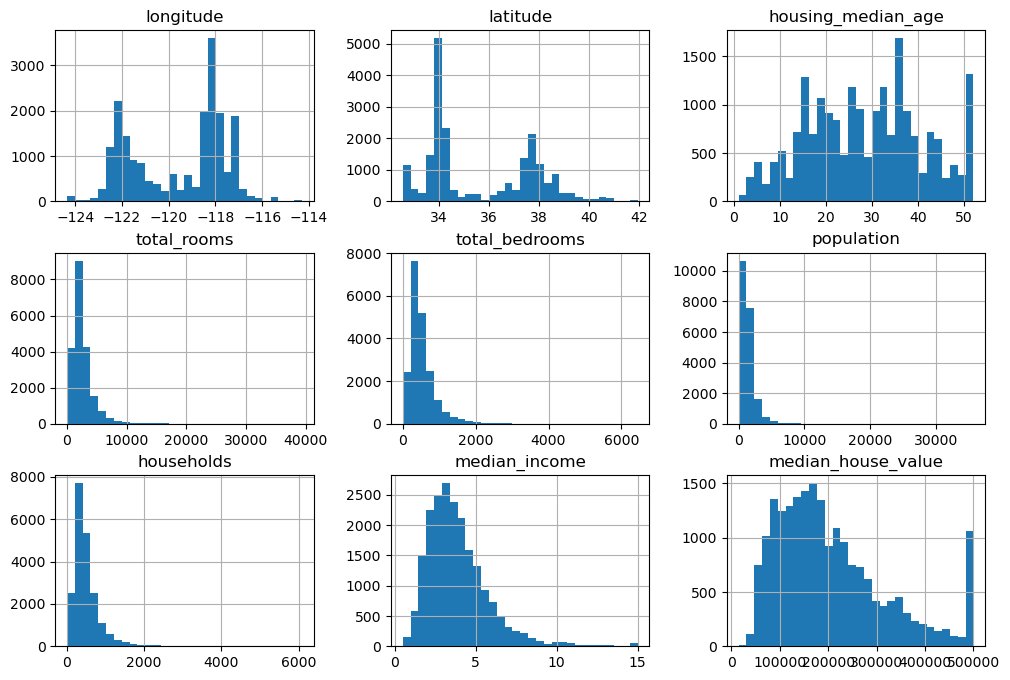

In [11]:
# This makes a plot of the distribution of numerical variables

# Observe how plt.tight_layout() fixes some issues with overlapping labels

import matplotlib.pyplot as plt
housing.hist(figsize=(12,8),bins=30)
#plt.tight_layout()
plt.show();

# Things to notice from this figure:
# 1. Lots of variables that are positive only, right skewed. This suggests applying some sort of transformation (like
# a log transform). This is even the case with the target, so we may need to transform back
# 2. Median house value seems to be "clipped", with a big bin right at 500k
# 3. housing median age seems to be multipeaked, building waves? (as are lat and longitude, but that makes sense)
# 4. There are a lot of what I would call "extensive" variables, variables which are are proportional to the population
# of a district. This includes total rooms, bedrooms, and households
# 5. These variables should probably be normalized to either population or to number of households
# 6. Median income has some outliers, and also looks potentially clipped

In [ ]:
# The next step is to create a test set. This is standard practice, and the test set is used to allow you
# to estimate out of sample performance of a trained model. Sometimes a validation set and a test set are both created,
# if there is going to be lots of hyperparameter tuning. Overfitting can happen in a number of tricky ways, and it can
# be caused simply by the data scientist seeing the test dataset before selecting the algorithms. Thus it is common
# practice across numerous fields to hide the test set before exploratory analysis occurs. A simple example of how 
# data can leak between training and testing sets is if you construct features using the full dataset. 

# sklearn has a built in function for splitting the data called train_test_split, but here is an example of
# some python code that does the same thing:

# Basically you randomly permute the indices, then pick the first group (up to the index designated by the 
# test ratio, to be the test set, and the rest to be the train indices). A tuple containing the training and testing
# sets is returned

# There are some issues around the randomization. You want to use the same random seed every time for this to avoid
# human bias. If your data set is going to change due to data being added, then there are extra considerations and
# methods to ensure that in the process of resplitting/examining your data that you don't end up seeing all of your
# data at some point in the training set. These are the hash based methods discussed in chapter 2, I'll skip
# them in this video because they aren't needed for this problem

def shuffle_and_split_data(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]


In [15]:
# Here is how we use the sklearn splitter

from sklearn.model_selection import train_test_split


train_set, test_set = train_test_split(housing, test_size=0.2, random_state=402)

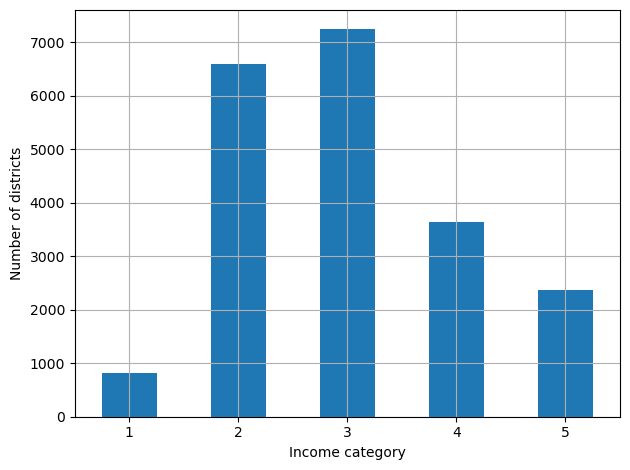

In [13]:
# Sometimes, it is important to make sure that the train test split isn't biased with respect to some variable of interest
# The idea is to make sure that you have a representative sample both in the training and testing split. This sort of
# procedure is key in several industries, such as polling, where polls are reweighted or corrected to adjust for the
# random (or biased) nature of the sampling. 

# The splitter has a "stratify" argument which can be used to make sure you have equal representation across the
# the selected classes.

# Let's say that we want to make sure we have equal representation across different income levels in the test and training
# sets. What we could do is create a new categorical variable using the cut method which bins districts by
# their median income, and then stratify based on that:

housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])
housing["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.tight_layout()
plt.show()


In [ ]:
# Now, to perform a stratified train-test split we do this:

strat_train_set, strat_test_set = train_test_split(
    housing, test_size=0.2, stratify=housing["income_cat"], random_state=402)

# And since we already have income as a variable we can drop the categories after the split:



for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)



In [66]:
housing_train = strat_train_set.drop("median_house_value", axis=1)
housing_train_labels = strat_train_set["median_house_value"].copy()

In [ ]:
# We will make a copy of our dataset to do our EDA/Feature Engineering
housing = strat_train_set.copy()

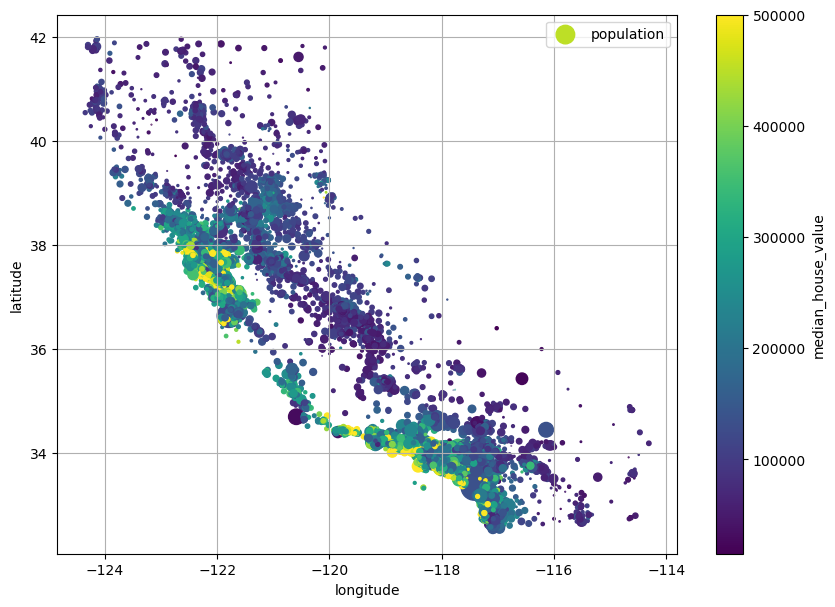

In [17]:
# Here are where the districts are located. Please don't use the 'jet' colormap like HOML does
# Perceptually uniform are superior, i.e. viridis, magma, etc

housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=housing["population"] / 100, label="population",
             c="median_house_value", cmap="viridis", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))
plt.show()

In [18]:
# This generates a matrix of correlation coefficients
corr_matrix = housing.corr(numeric_only=True)

In [19]:
# This is our target value, let's see what correlates with it:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

In [ ]:
# I think the extensive values provide little information, even if they seem important, i.e. total_rooms, 
# households, total_bedrooms, population. They are all very strongly correlated with each other

corr_matrix["population"].sort_values(ascending=False)


population            1.000000
households            0.907222
total_bedrooms        0.877747
total_rooms           0.857126
longitude             0.099773
median_income         0.004834
median_house_value   -0.024650
latitude             -0.108785
housing_median_age   -0.296244
Name: population, dtype: float64

In [22]:
# Here we have normalized the extensive variables to either population, households, or total rooms

housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

In [23]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
rooms_per_house       0.151948
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
people_per_house     -0.023737
population           -0.024650
longitude            -0.045967
latitude             -0.144160
bedrooms_ratio       -0.255880
Name: median_house_value, dtype: float64

In [ ]:
# I would drop the extensive values, though HOML doesn't. We will keep just the population. It would be 
# reasonable to correct the error if we were doing a linear regression to weight according to population to
# correct for heteroscedasticity


housing.drop(['total_rooms','total_bedrooms','households'],axis=1, inplace=True)

KeyError: "['total_rooms', 'total_bedrooms', 'households'] not found in axis"

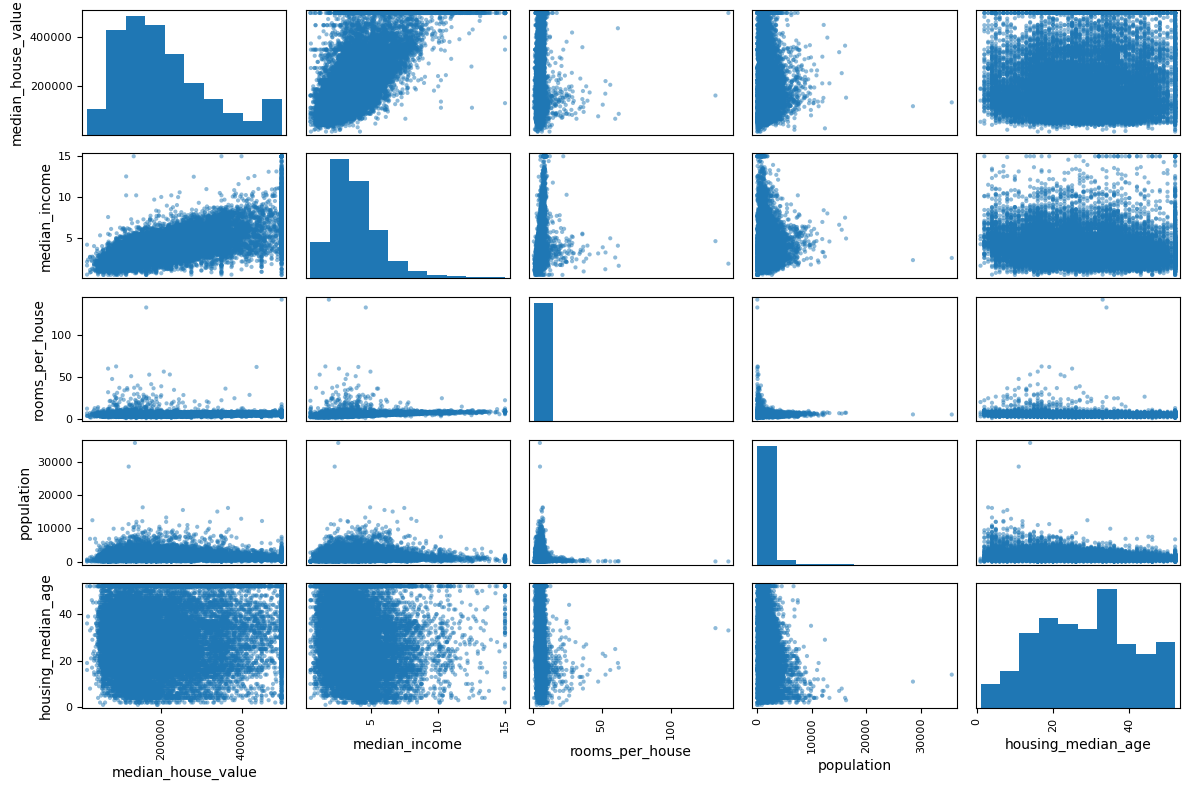

In [27]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "rooms_per_house","population",
              "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.tight_layout()
plt.show()

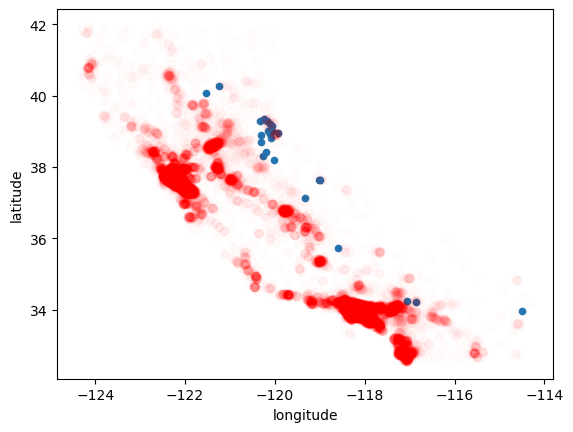

In [ ]:
# I think the most mysterious thing you should see are the districts where the rooms_per_house is excessive, like greater than 30.
# Other interesting features are the bars at high median income and the heteroscedasticity. 
# The high rooms per house are in certain areas (around lake Tahoe, I think they are ski resorts)
# You would need to sort this stuff out if working on this professionally

housing.query("rooms_per_house >30").plot(kind="scatter",x="longitude",y="latitude",s=20)
plt.scatter(x=housing["longitude"],y=housing["latitude"],color="red",alpha=0.01)


In [52]:
# Handling null values

# There are a few ways to do this, either you discard the rows with null values, discard the column with null values (i.e. just abandon that variable)
# or do imputation. There is not a rule about what you should do, you have to use your best judgement. It is critical to consider why the values
# might be missing, and what impact each choice could have on the analysis. For example, if values are missing for records which are critically
# important to the performance of the algorithm, dropping those observations may not be an option because of how it will bias your modeling.

# In this case, imputation (using some sort of modeling) or discarding the entire variable are the best choices. 

# Something about imputation has always bothered me. I think that if you impute you should add a variable to the dataset indicating if the observation
# was imputed and see how it impacts the model

# For this analysis we are going to impute the median, there are only 7 missing values we could easily discard them but we will stick with the text


housing.info()



<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20640 non-null  float64 
 1   latitude            20640 non-null  float64 
 2   housing_median_age  20640 non-null  float64 
 3   population          20640 non-null  float64 
 4   median_income       20640 non-null  float64 
 5   median_house_value  20640 non-null  float64 
 6   ocean_proximity     20640 non-null  str     
 7   income_cat          20640 non-null  category
 8   rooms_per_house     20640 non-null  float64 
 9   bedrooms_ratio      20433 non-null  float64 
 10  people_per_house    20640 non-null  float64 
dtypes: category(1), float64(9), str(1)
memory usage: 1.6 MB


In [53]:
# We will use an imputer to do this since it shows off the most unfamiliar feature. An imputer is one of the fundamental types of 
# transfomer objects in scikit learn (others are things like the scalers)

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
housing_num = housing.select_dtypes(include=[np.number])
imputer.fit(housing_num)
X = imputer.transform(housing_num) # This creates a numpy array with the transformed (imputed values replaced)
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing_num.index)


In [56]:
# Our algorithm will need to deal with categorical variables. Some methods handle it naturally, such
# as regular linear regression. But many do not. For the one categorical variable, we could attempt to give it an ordinal structure, it is still somewhat
# vague to decide what the levels should be.

# But the other way is something called one-hot encoding. It creates a new column for each categorical value

housing_cat = housing[["ocean_proximity"]]

housing_cat.value_counts()

from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

housing_cat_1hot



<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 20640 stored elements and shape (20640, 5)>

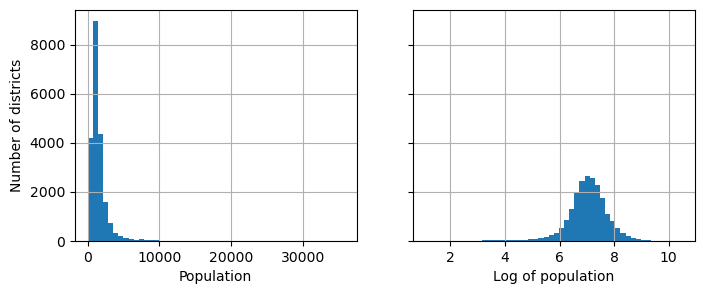

In [59]:
# We are going to want to do a few different transformations to the numerical features:

# 1. We will apply the log transformation to a few variables that are positive and have a right skew
# This includes 
# 2. We will use the standard scaler to transform variables to having mean 0 and variance 1


fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing["population"].hist(ax=axs[0], bins=50)
housing["population"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Population")
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")

plt.show()



from sklearn.compose import TransformedTargetRegressor









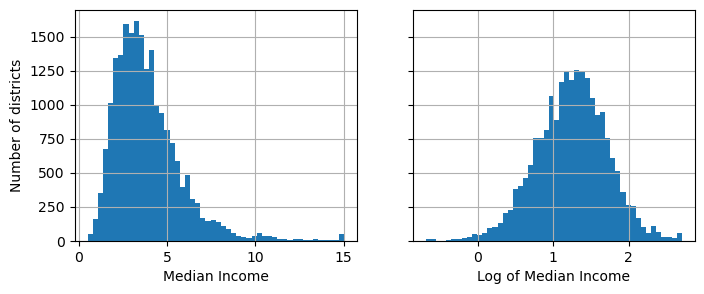

In [60]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing["median_income"].hist(ax=axs[0], bins=50)
housing["median_income"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Median Income")
axs[1].set_xlabel("Log of Median Income")
axs[0].set_ylabel("Number of districts")

plt.show()

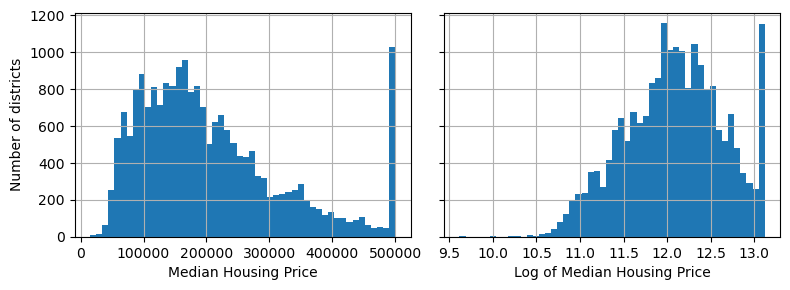

In [63]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing["median_house_value"].hist(ax=axs[0], bins=50)
housing["median_house_value"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Median Housing Price")
axs[1].set_xlabel("Log of Median Housing Price")
axs[0].set_ylabel("Number of districts")
plt.tight_layout()
plt.show()

In [69]:
from sklearn.preprocessing import StandardScaler


,longitude,latitude,housing_median_age,population,median_income,median_house_value,ocean_proximity,income_cat,rooms_per_house,bedrooms_ratio,people_per_house
0,-122.23,37.88,41.0,322.0,8.3252,452600.0,NEAR BAY,5,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,2401.0,8.3014,358500.0,NEAR BAY,5,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,496.0,7.2574,352100.0,NEAR BAY,5,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,558.0,5.6431,341300.0,NEAR BAY,4,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,565.0,3.8462,342200.0,NEAR BAY,3,6.281853,0.172096,2.181467
...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,845.0,1.5603,78100.0,INLAND,2,5.045455,0.224625,2.560606
20636,-121.21,39.49,18.0,356.0,2.5568,77100.0,INLAND,2,6.114035,0.215208,3.122807
20637,-121.22,39.43,17.0,1007.0,1.7000,92300.0,INLAND,2,5.205543,0.215173,2.325635
20638,-121.32,39.43,18.0,741.0,1.8672,84700.0,INLAND,2,5.329513,0.219892,2.123209


In [ ]:
# Now it is time to put it all together into one pipeline that does all of the preprocessing steps

# A pipeline is a sequence of data processing components. Most machine learning systems are structured using pipelines, and
# idiomatic sklearn makes extensive use of pipelines. Here we are going to build such a pipeline. It is going to do the following things from the
# original dataset

# 1. Create the new features, which are the "intensive variables", i.e. the rooms/household, bedrooms/rooms, people/household
# 2. Discard some of the extensive variables, i.e. total households, total rooms, total bedrooms
# 3. Impute missing values in the numerical variables using the median values
# 4. Log transform the the right skewed, positive variables, i.e. median income, population, and the target which is price
# 5. Apply the standard scaler to the numerical variables
# 6. Perform One-Hot encoding on the categorical variable ocean-proximity

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import FunctionTransformer

# Basically this takes anumpy array or data frame and divides the first column by the second
 



def column_ratio(X):
    return X[:, [0]] / X[:, [1]]


# This is just a helper function to add the names of the ratios
def ratio_name(function_transformer, feature_names_in):
    return ["ratio"] 

# We put together all the steps in making the ratio variables, impute, call the column ratio
# function using FunctionTransformer. The function transformer will have all the needed methods of a sklearn pipeline

# make_pipeline is a simple way to string together the components/transformations/models of a given pipeline. It automatically names
# the given elements of a pipeline. 

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler())


# This pipeline applies the log transform and the standard scaler. the log1p evaluates log1p(0)=0 rather than NaN. Just be aware of that

log_pipeline = make_pipeline(
    FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
    StandardScaler())


# The ColumnTransformer function is key to coding this process in a compact and easy way.

# This unction applies different transformations to subsets of columns and then puts the result together (either of a pandas data frame or
# numpy array)
# For example, the first three entries in this function create the ratios. Each one returns a single column
# Then the next one applies the log transform to population and median income
# Then the cat

preprocessing = ColumnTransformer([
        ("bedrooms_ratio", ratio_pipeline(), ["total_bedrooms", "total_rooms"]), 
        ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
        ("people_per_house", ratio_pipeline(), ["population", "households"]),
        ("log", log_pipeline, ["population", "median_income"]),
        ("cat",OneHotEncoder(),[ make_column_selector(dtype_include=object)]),
    ],
    remainder=StandardScaler())  

# This transforms our training data


# Notice the use of fit_transform. This "learns" the properties of our training data then applies the transformation

housing_train_prep = preprocessing.fit_transform(housing_train)


# This here uses only transform. This applies the transformation, this ensures no data leakagae from the training to the test set

housing_test = strat_test_set.drop("median_house_value", axis=1)
housing_test_labels = strat_test_set["median_house_value"].copy()
housing_test_prep = preprocessing.transform(housing_test)




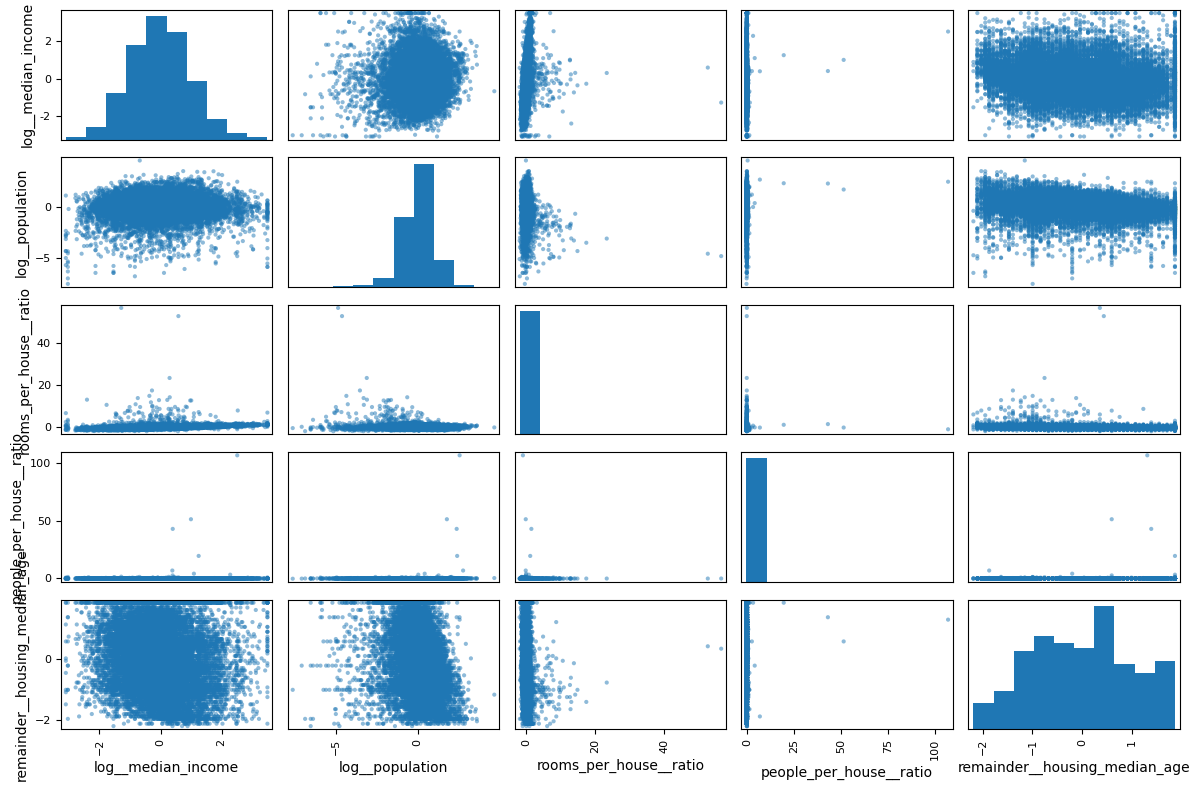

In [98]:
housing_train_prep_df = pd.DataFrame(
    housing_train_prep,
    columns=preprocessing.get_feature_names_out(),
    index=housing_train.index
)

attributes = ["log__median_income", "log__population", "rooms_per_house__ratio","people_per_house__ratio",
              "remainder__housing_median_age"]

scatter_matrix(housing_train_prep_df[attributes], figsize=(12, 8))
plt.tight_layout()
plt.show()

In [92]:
housing_train_prep_df

,bedrooms_ratio__ratio,rooms_per_house__ratio,people_per_house__ratio,log__population,log__median_income,cat__ocean_proximity_<1H OCEAN,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN,remainder__longitude,remainder__latitude,remainder__housing_median_age
13419,-0.979161,0.550118,-0.021433,-0.096174,1.040905,0.0,0.0,0.0,1.0,0.0,-1.256115,0.985047,0.272016
8767,-1.055108,0.011311,-0.052450,-0.248551,1.196962,0.0,1.0,0.0,0.0,0.0,1.156358,-0.691474,-0.203706
10319,0.300907,-0.519148,0.586262,1.317844,-0.260532,1.0,0.0,0.0,0.0,0.0,0.692805,-0.738435,0.509876
1586,0.203022,-0.384553,0.052234,0.643714,0.264685,0.0,0.0,0.0,0.0,1.0,-1.440539,0.975655,1.382032
7983,0.243192,-0.381254,-0.069230,-0.244237,-1.841475,0.0,1.0,0.0,0.0,0.0,-1.350819,2.238916,-0.203706
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13216,1.124927,-0.644651,-0.117597,-0.114307,-0.357931,0.0,0.0,0.0,0.0,1.0,1.161343,-1.292579,-1.075861
2333,-0.142219,-0.279526,-0.006012,-0.327130,-0.139061,1.0,0.0,0.0,0.0,0.0,0.707758,-0.808877,0.827024
17461,0.644906,-0.616431,0.000065,-0.035793,0.511052,0.0,0.0,0.0,0.0,1.0,-1.420602,0.956870,0.272016
3089,0.399070,-0.358404,-0.089588,0.252247,-0.025621,1.0,0.0,0.0,0.0,0.0,0.662898,-0.663297,0.589163


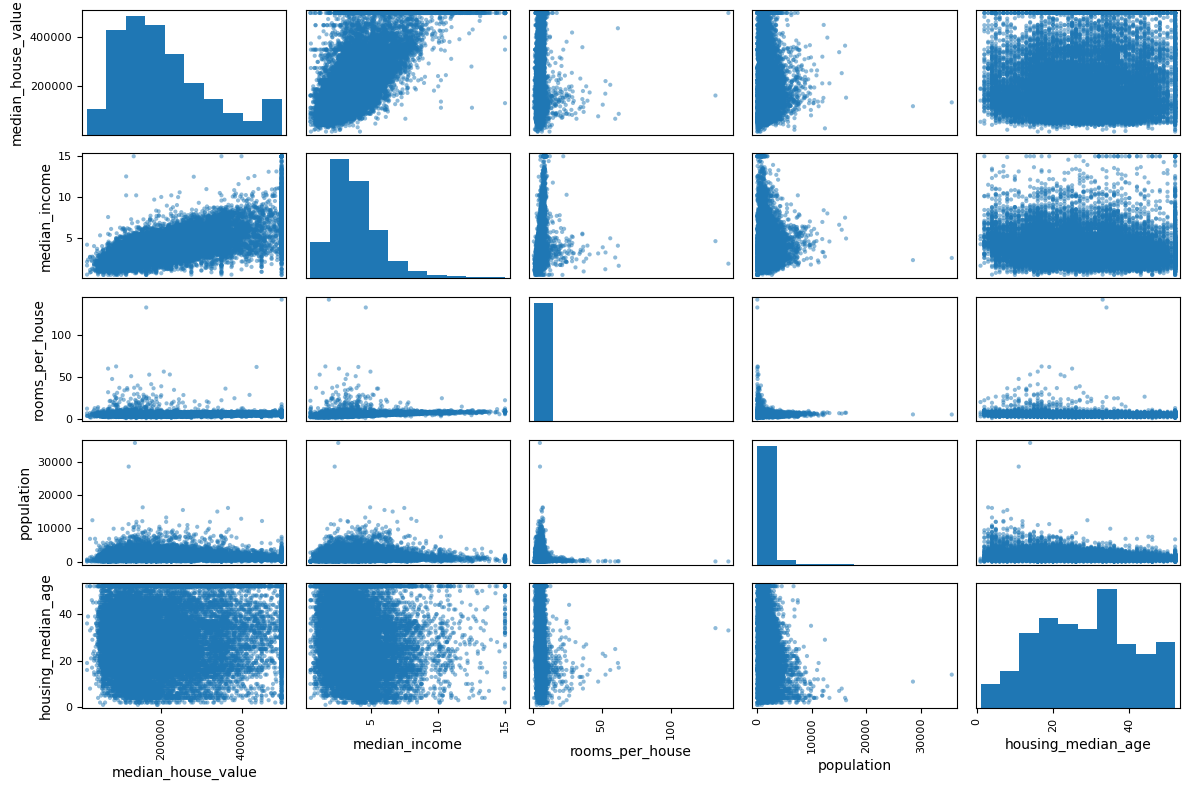

In [73]:

attributes = ["median_house_value", "median_income", "rooms_per_house","population",
              "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.tight_layout()
plt.show()

In [146]:
# Time to model.

# We are going to build a baseline linear regression model that uses all of the features and test the performance. We will use the log
# transformation on the target and show you how to do that, and then show how to incorporate everything into a nice pipeline

from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# This fits a linear model to our transformed data

linear_model = LinearRegression()
linear_model.fit(housing_train_prep, housing_train_labels)

predictions = linear_model.predict(housing_test_prep)

rmse = np.sqrt(mean_squared_error(housing_test_labels, predictions))
mae = mean_absolute_error(housing_test_labels,predictions)
print(f"RMSE: {rmse:,.2f}")
print(f"MAE: {mae:,.2f}")


# To fit a model to the log we use TransformedTargetRegressor like this:
# This applies the log transformation to the target. Notice we need to supply an inverse transformation

log_linear_model = TransformedTargetRegressor(
    regressor=LinearRegression(),
    func=np.log,           
    inverse_func=np.exp    
)

log_linear_model.fit(housing_train_prep, housing_train_labels)


ll_predictions = log_linear_model.predict(housing_test_prep)

# Evaluate
rmse = np.sqrt(mean_squared_error(housing_test_labels, ll_predictions))
mae = mean_absolute_error(housing_test_labels,ll_predictions)

print(f"RMSE: {rmse:,.2f}")
print(f"MAE: {mae:,.2f}")

# Note the big drop in MAE for the log-linear model. This is because when you fit the log transformed target, you are handling the heteroscedasticity
# and as a result the fit prioritizes errors at "lower" values of the price variable. Wnen you compare on the original target, the errors
# you make at higher price get exponentiated and so contribute more.


RMSE: 73,383.61
MAE: 55,332.41
RMSE: 72,377.98
MAE: 49,987.39


In [144]:

train_predictions = linear_model.predict(housing_train_prep)
test_predictions = linear_model.predict(housing_test_prep)

test_rmse = np.sqrt(mean_squared_error(housing_test_labels,test_predictions))
train_rmse = np.sqrt(mean_squared_error(housing_train_labels,train_predictions))

test_rmse
train_rmse

np.float64(73339.49971557138)

In [145]:
# How would we explore the pattern of residuals and the importance of each transformed feature?

# Start with importance


feature_names = preprocessing.get_feature_names_out()
coefficients = log_linear_model.regressor_.coef_ # Have to get the regressor out of the transformer object

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
})

# We sort by magnitude

coef_df.sort_values('coefficient', ascending=False).head(20)

# We can see that in this model, rich places have expensive homes, islands are expensive, inland is cheap
# the more bedrooms per room and rooms per house are expensive, and the more people per house is cheaper

,feature,coefficient
4,log__median_income,0.357058
7,cat__ocean_proximity_ISLAND,0.308773
0,bedrooms_ratio__ratio,0.070738
1,rooms_per_house__ratio,0.033224
12,remainder__housing_median_age,0.028634
3,log__population,0.001201
8,cat__ocean_proximity_NEAR BAY,-0.001811
5,cat__ocean_proximity_<1H OCEAN,-0.002904
9,cat__ocean_proximity_NEAR OCEAN,-0.008183
2,people_per_house__ratio,-0.014618


<positron-console-cell-148>:38: RuntimeWarning: invalid value encountered in log
<positron-console-cell-148>:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


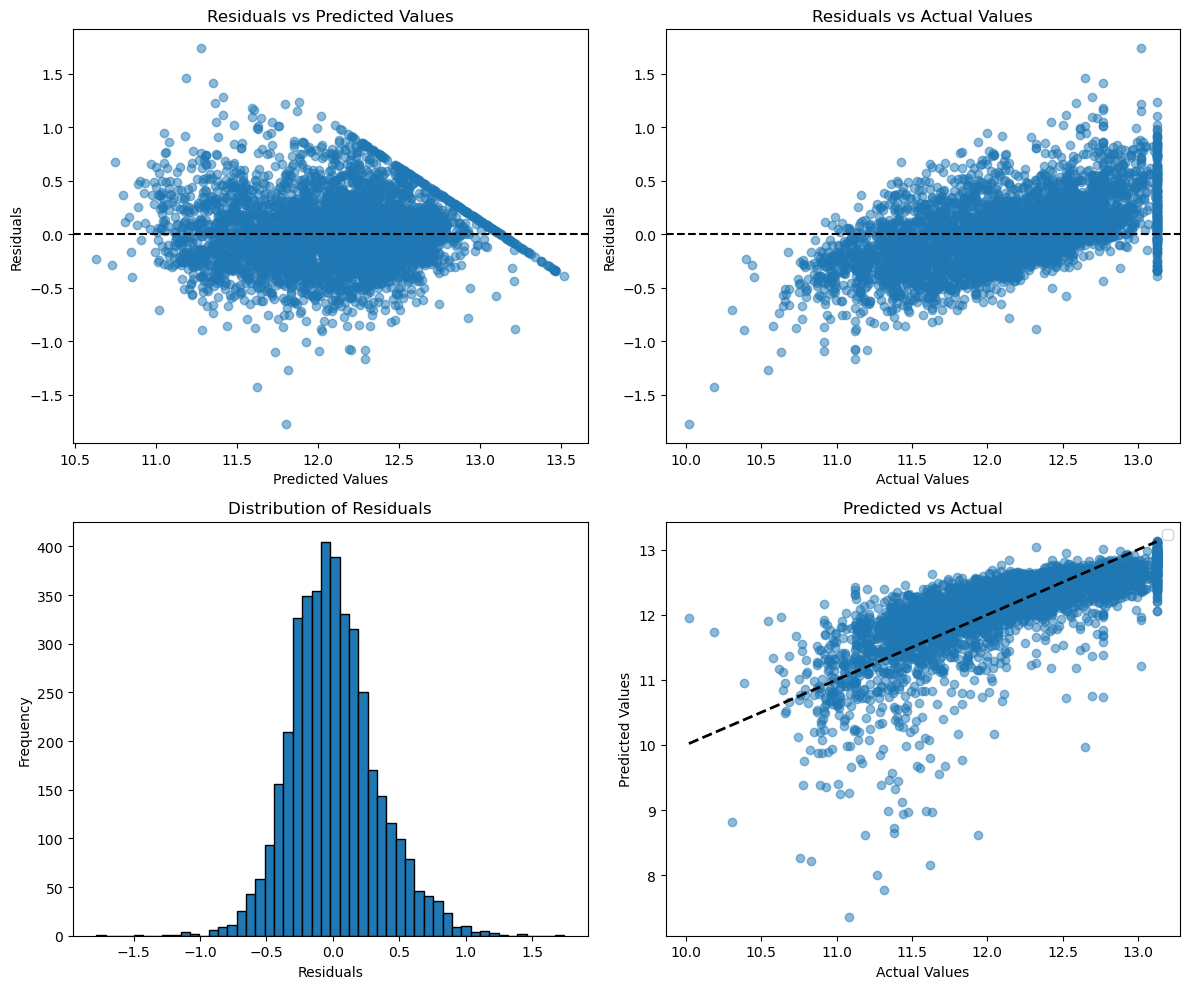

In [148]:
# Here we are going to take a look at what the model is actually doing. This is 
# often a really important step for gaining an understanding

# We just subtract the true price from the predictions. I feel like I should keep this in log
# space


###


residuals = np.log(housing_test_labels) - np.log(ll_predictions)

# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Residuals vs Predicted Values
axes[0, 0].scatter(np.log(ll_predictions), residuals, alpha=0.5)
axes[0, 0].axhline(y=0, color='k', linestyle='--')
axes[0, 0].set_xlabel('Predicted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Predicted Values')

# Plot 2: Residuals vs Actual Values
axes[0, 1].scatter(np.log(housing_test_labels), residuals, alpha=0.5)
axes[0, 1].axhline(y=0, color='k', linestyle='--')
axes[0, 1].set_xlabel('Actual Values')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residuals vs Actual Values')

# Plot 3: Histogram of Residuals
axes[1, 0].hist((residuals), bins=50, edgecolor='black')
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Residuals')

# Plot 4: Predicted vs Actual

axes[1, 1].scatter(np.log(housing_test_labels), np.log(predictions), alpha=0.5)
axes[1, 1].plot([np.log(housing_test_labels.min()), np.log(housing_test_labels.max())], 
                [np.log(housing_test_labels.min()), np.log(housing_test_labels.max())], 
                'k--', lw=2)
axes[1, 1].set_xlabel('Actual Values')
axes[1, 1].set_ylabel('Predicted Values')
axes[1, 1].set_title('Predicted vs Actual')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

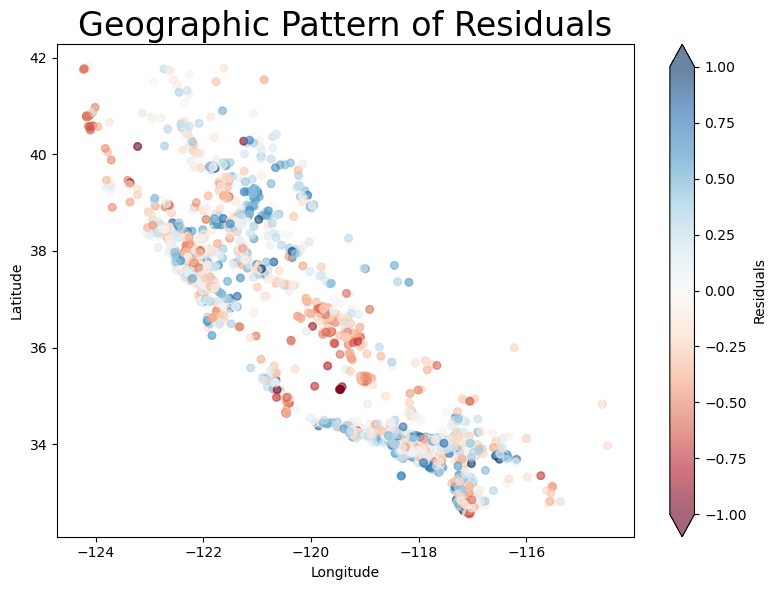

In [149]:

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    housing_test['longitude'], 
    housing_test['latitude'],
    c=residuals,
    cmap='RdBu',  
    alpha=0.6,
    s=30,
    vmin=-1,  
    vmax=1
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Geographic Pattern of Residuals',fontsize=24)
plt.colorbar(scatter,extend="both", label='Residuals')

plt.tight_layout()
plt.show()

In [118]:
# Let's try a knn model
from sklearn.neighbors import KNeighborsRegressor
knn_model = KNeighborsRegressor(n_neighbors=10)
knn_model.fit(housing_train_prep, housing_train_labels)

predictions = knn_model.predict(housing_test_prep)

rmse = np.sqrt(mean_squared_error(housing_test_labels, predictions))
mae = mean_absolute_error(housing_test_labels,predictions)
print(f"RMSE: {rmse:,.2f}")
print(f"MAE: {mae:,.2f}")

RMSE: 62,783.17
MAE: 43,011.86


<positron-console-cell-150>:1: RuntimeWarning: invalid value encountered in log


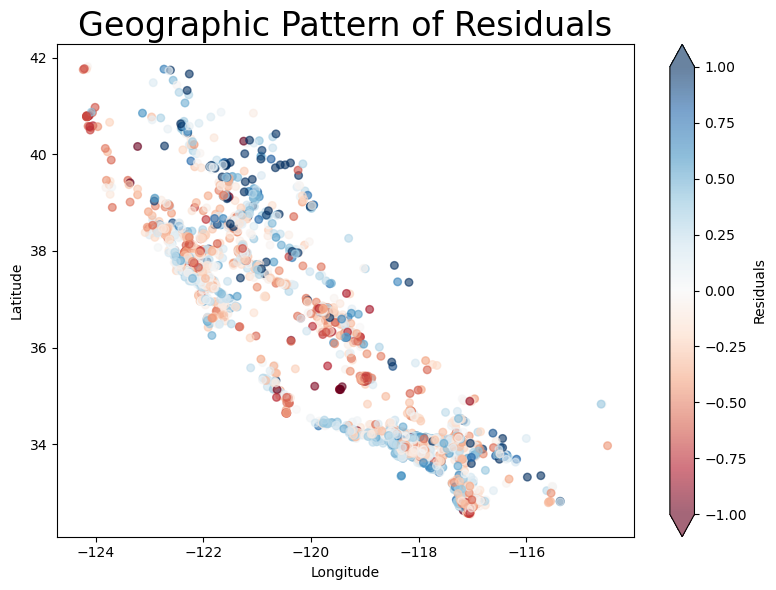

In [150]:
residuals = np.log(housing_test_labels) - np.log(predictions)
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    housing_test['longitude'], 
    housing_test['latitude'],
    c=residuals,
    cmap='RdBu',  
    alpha=0.6,
    s=30,
    vmin=-1,  
    vmax=1
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Geographic Pattern of Residuals',fontsize=24)
plt.colorbar(scatter,extend="both", label='Residuals')

plt.tight_layout()
plt.show()

In [141]:
# How to make a full pipeline

linear_regression_pipeline = Pipeline([
    ('preprocessing', preprocessing),  
    ('model', TransformedTargetRegressor(
        regressor=LinearRegression(),
        func=np.log,
        inverse_func=np.exp
    ))
])

knn_regression_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('model', KNeighborsRegressor(n_neighbors=5))
])



knn_regression_pipeline.fit(housing_train, housing_train_labels)


predictions_knn = knn_regression_pipeline.predict(housing_test)


rmse = np.sqrt(mean_squared_error(housing_test_labels, predictions_knn))
print(f"KNN RMSE: {rmse:,.2f}")


KNN RMSE: 64,480.66
